In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('cleaned_churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7032, 21)

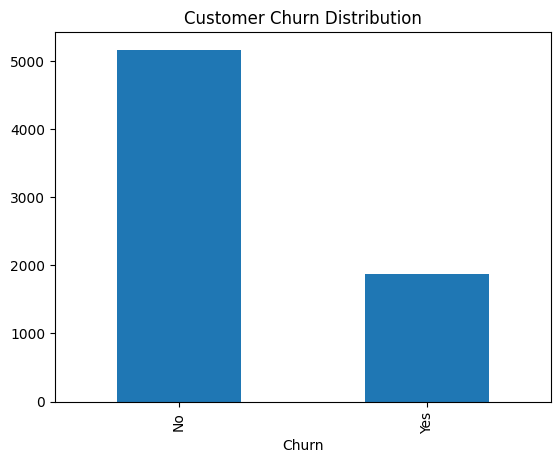

In [5]:
# Visualizing the churn
df['Churn'].value_counts().plot(kind='bar')
plt.title('Customer Churn Distribution')
plt.show()

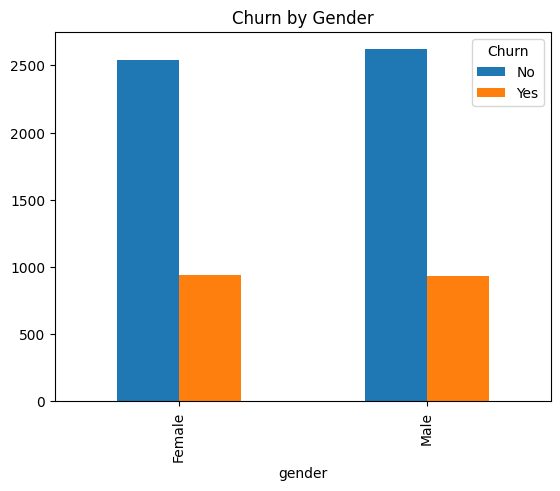

In [7]:
# Churn by Gender
pd.crosstab(df['gender'],df['Churn']).plot(kind='bar')
plt.title('Churn by Gender')
plt.show()

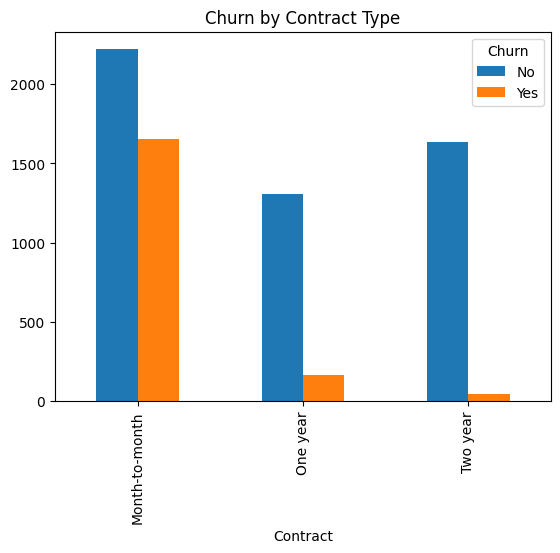

In [9]:
# Churn by Contract Type
pd.crosstab(df['Contract'],df['Churn']).plot(kind='bar')
plt.title('Churn by Contract Type')
plt.show()

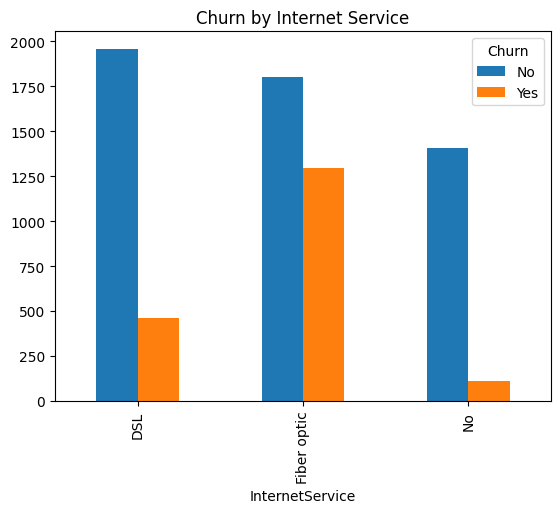

In [10]:
# Churn by Internet Service
pd.crosstab(df['InternetService'],df['Churn']).plot(kind='bar')
plt.title('Churn by Internet Service')
plt.show()

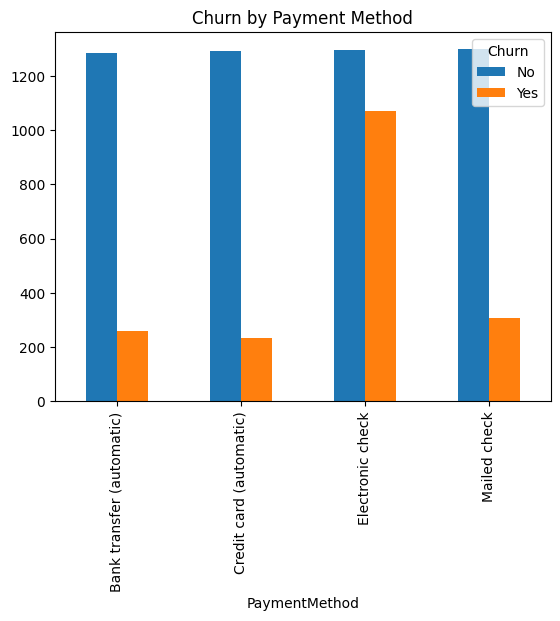

In [11]:
# Churn by Payment Method
pd.crosstab(df['PaymentMethod'],df['Churn']).plot(kind='bar')
plt.title('Churn by Payment Method')
plt.show()

In [13]:
# Monthly charges
df.groupby('Churn')['MonthlyCharges'].mean()

,MonthlyCharges
Churn,
No,61.307408
Yes,74.441332


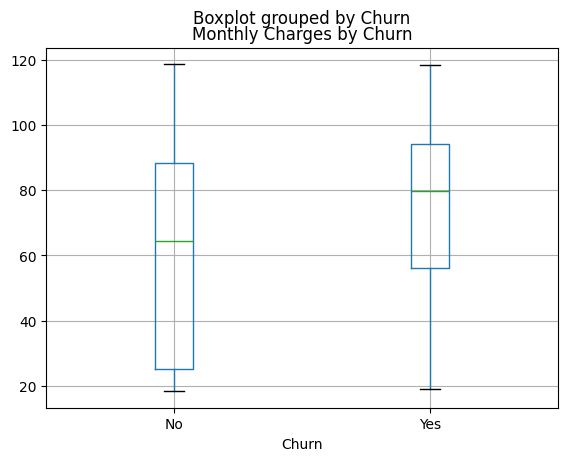

In [14]:
# Visualixation
df.boxplot(column='MonthlyCharges',by='Churn')
plt.title('Monthly Charges by Churn')
plt.show()

In [15]:
# Tenure Analysis
df.groupby('Churn')['tenure'].mean()

,tenure
Churn,
No,37.650010
Yes,17.979133


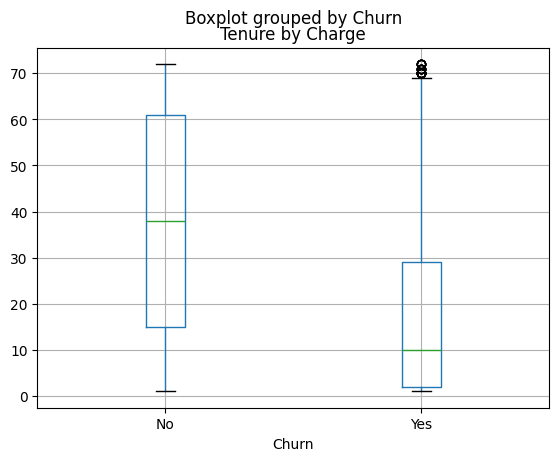

In [16]:
df.boxplot(column='tenure',by='Churn')
plt.title('Tenure by Charge')
plt.show()

In [18]:
df['Churn'] = df['Churn'].map({
    'No': 0,
    'Yes': 1
})

In [19]:
# Correlation Analysis
df[['tenure','MonthlyCharges','TotalCharges','Churn']].corr()

,tenure,MonthlyCharges,TotalCharges,Churn
tenure,1.000000,0.246862,0.825880,-0.354049
MonthlyCharges,0.246862,1.000000,0.651065,0.192858
TotalCharges,0.825880,0.651065,1.000000,-0.199484
Churn,-0.354049,0.192858,-0.199484,1.000000


In [22]:
corr_matrix = df[['tenure',
                  'MonthlyCharges',
                  'TotalCharges',
                  'Churn']].corr()

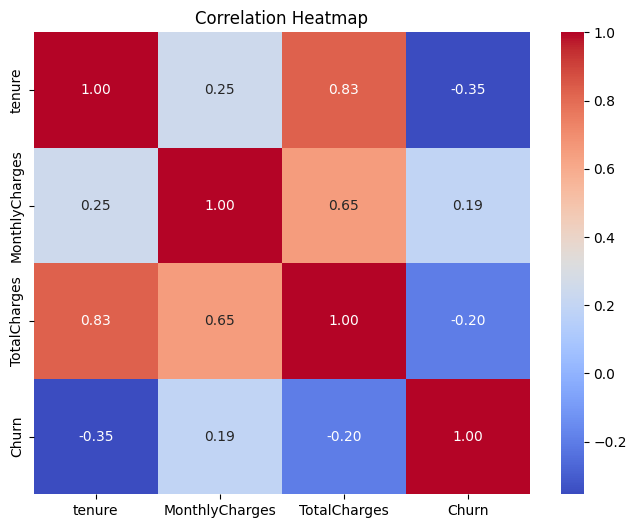

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.show()

Key findings
1. Month to Month Contract Type are more likely to churn.
2. Customer who are paying more are more likely to churn.
3. Customers using electronic check are more likely to churn.
4. Monthly charge plays important role in more churn customer.